# Markov Chain & Capacity Factor Analysis
**Berdasarkan Bab III.3.3.1 & Lampiran 5 — Data BMKG Tardamu 2025**

In [1]:
"""
================================================================================
SIMULASI BAGIAN 4: MARKOV CHAIN & CAPACITY FACTOR
Berdasarkan Bab III.3.3.1 & Lampiran 5 — Data BMKG Tardamu 2025
================================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.linalg import eig
import warnings
warnings.filterwarnings('ignore')

# ─── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D2E',
    'axes.edgecolor':    '#2E3250',
    'axes.labelcolor':   '#E0E0F0',
    'axes.titlecolor':   '#FFFFFF',
    'axes.grid':         True,
    'grid.color':        '#2E3250',
    'grid.linewidth':    0.6,
    'xtick.color':       '#A0A8C0',
    'ytick.color':       '#A0A8C0',
    'text.color':        '#E0E0F0',
    'legend.facecolor':  '#1E2235',
    'legend.edgecolor':  '#3A3F60',
    'legend.labelcolor': '#E0E0F0',
    'font.family':       'DejaVu Sans',
    'font.size':         10,
})

# Colour palette
C_LOW    = '#FF4C6A'   # red-pink  → Low state
C_NORM   = '#4C9EFF'   # sky blue  → Normal state
C_MEAN   = '#FFD166'   # amber     → mean lines
C_BAND   = '#7B68EE'   # medium-slate → confidence bands
C_WHITE  = '#FFFFFF'
C_FAINT  = '#A0A8C0'

In [2]:
# ============================================================================
# 1. PARAMETERS (dari Lampiran 5)
# ============================================================================

PARAMS = {
    'N_obs':      304,      # Jumlah observasi valid
    'mean_CF':    0.3123,   # Rata-rata Capacity Factor
    'std_CF':     0.0683,   # Standar deviasi CF
    'CF_min':     0.0,
    'CF_max':     0.3333,   # 8 jam penyinaran
    'threshold':  0.30,     # Batas Low / Normal
    'p_L':        0.1053,   # Probabilitas Low
    'p_N':        0.8947,   # Probabilitas Normal
    'CF_Low':     0.1342,   # CF rerata saat Low
    'CF_Normal':  0.3333,   # CF rerata saat Normal
}

SIM = {
    'n_years': 50,
    'n_sim':   1000,
    'seed':    42,
}

print("Parameters loaded OK.")
print(f"  p_L={PARAMS['p_L']}, p_N={PARAMS['p_N']}")
print(f"  CF_Low={PARAMS['CF_Low']}, CF_Normal={PARAMS['CF_Normal']}")

Parameters loaded OK.
  p_L=0.1053, p_N=0.8947
  CF_Low=0.1342, CF_Normal=0.3333


In [3]:
# ============================================================================
# 2. GENERATE SYNTHETIC DATA  (no null values)
# ============================================================================

np.random.seed(SIM['seed'])

n      = PARAMS['N_obs']
n_low  = int(round(n * PARAMS['p_L']))
n_norm = n - n_low

# Low state samples — clipped strictly below threshold
low_raw  = np.random.normal(PARAMS['CF_Low'],  PARAMS['std_CF'] * 0.50, size=n_low  * 3)
low_raw  = low_raw[(low_raw > 0) & (low_raw < PARAMS['threshold'])]
low_raw  = low_raw[:n_low]                     # take exactly n_low valid samples

# Normal state samples — clipped at [threshold, CF_max]
norm_raw = np.random.normal(PARAMS['CF_Normal'], PARAMS['std_CF'] * 0.30, size=n_norm * 3)
norm_raw = norm_raw[(norm_raw >= PARAMS['threshold']) & (norm_raw <= PARAMS['CF_max'])]
norm_raw = norm_raw[:n_norm]

# Combine & shuffle
CF_data = np.concatenate([low_raw, norm_raw])
np.random.shuffle(CF_data)

# Guard: ensure no NaN or out-of-range values
assert len(CF_data) == n,            "Length mismatch after clipping"
assert not np.any(np.isnan(CF_data)),"NaN values detected — aborting"
assert CF_data.min() >= 0,           "Negative CF detected — aborting"
assert CF_data.max() <= PARAMS['CF_max'], "CF exceeds maximum — aborting"

state_data = np.where(CF_data < PARAMS['threshold'], 'Low', 'Normal')
SS_data    = CF_data * 24

# Derived stats (used for annotation later)
p_L_emp  = np.mean(state_data == 'Low')
p_N_emp  = 1 - p_L_emp
CF_L_emp = CF_data[state_data == 'Low'].mean()
CF_N_emp = CF_data[state_data == 'Normal'].mean()

print(f"Synthetic data OK — {n} samples, 0 NaN")
print(f"  Empirical p_L={p_L_emp:.4f}  (target {PARAMS['p_L']})")
print(f"  Empirical p_N={p_N_emp:.4f}  (target {PARAMS['p_N']})")
print(f"  Empirical CF_Low={CF_L_emp:.4f}  CF_Normal={CF_N_emp:.4f}")

Synthetic data OK — 304 samples, 0 NaN
  Empirical p_L=0.1053  (target 0.1053)
  Empirical p_N=0.8947  (target 0.8947)
  Empirical CF_Low=0.1295  CF_Normal=0.3195


In [4]:
# ============================================================================
# 3. MARKOV CHAIN SIMULATION
# ============================================================================

np.random.seed(SIM['seed'])

# Draw states: 0 = Low, 1 = Normal  (i.i.d. — stationarity assumption)
states = np.random.choice(
    [0, 1],
    size=(SIM['n_sim'], SIM['n_years']),
    p=[PARAMS['p_L'], PARAMS['p_N']]
)
CF_mc = np.where(states == 0, PARAMS['CF_Low'], PARAMS['CF_Normal'])  # no NaN possible

years    = np.arange(1, SIM['n_years'] + 1)
prob_L   = np.mean(states == 0, axis=0)   # proportion Low per year across simulations
prob_N   = 1 - prob_L
mean_CF  = CF_mc.mean(axis=0)
std_CF   = CF_mc.std(axis=0)
p10      = np.percentile(CF_mc, 10, axis=0)
p90      = np.percentile(CF_mc, 90, axis=0)

# Low-state frequency per simulation
freq_low = states.sum(axis=0) == 0  # dummy — we want per-simulation
n_low_per_sim    = (states == 0).sum(axis=1)          # shape (n_sim,)
pct_low_per_sim  = n_low_per_sim / SIM['n_years'] * 100

# Stationary distribution (via eigendecomposition)
P = np.array([[PARAMS['p_L'], PARAMS['p_N']],
              [PARAMS['p_L'], PARAMS['p_N']]])
eigvals, eigvecs = eig(P.T)
idx = np.argmin(np.abs(eigvals - 1))
pi  = np.real(eigvecs[:, idx])
pi /= pi.sum()

print(f"Simulation OK — {SIM['n_sim']} paths × {SIM['n_years']} years")
print(f"  Stationary dist: π_Low={pi[0]:.4f}  π_Normal={pi[1]:.4f}")

Simulation OK — 1000 paths × 50 years
  Stationary dist: π_Low=0.1053  π_Normal=0.8947


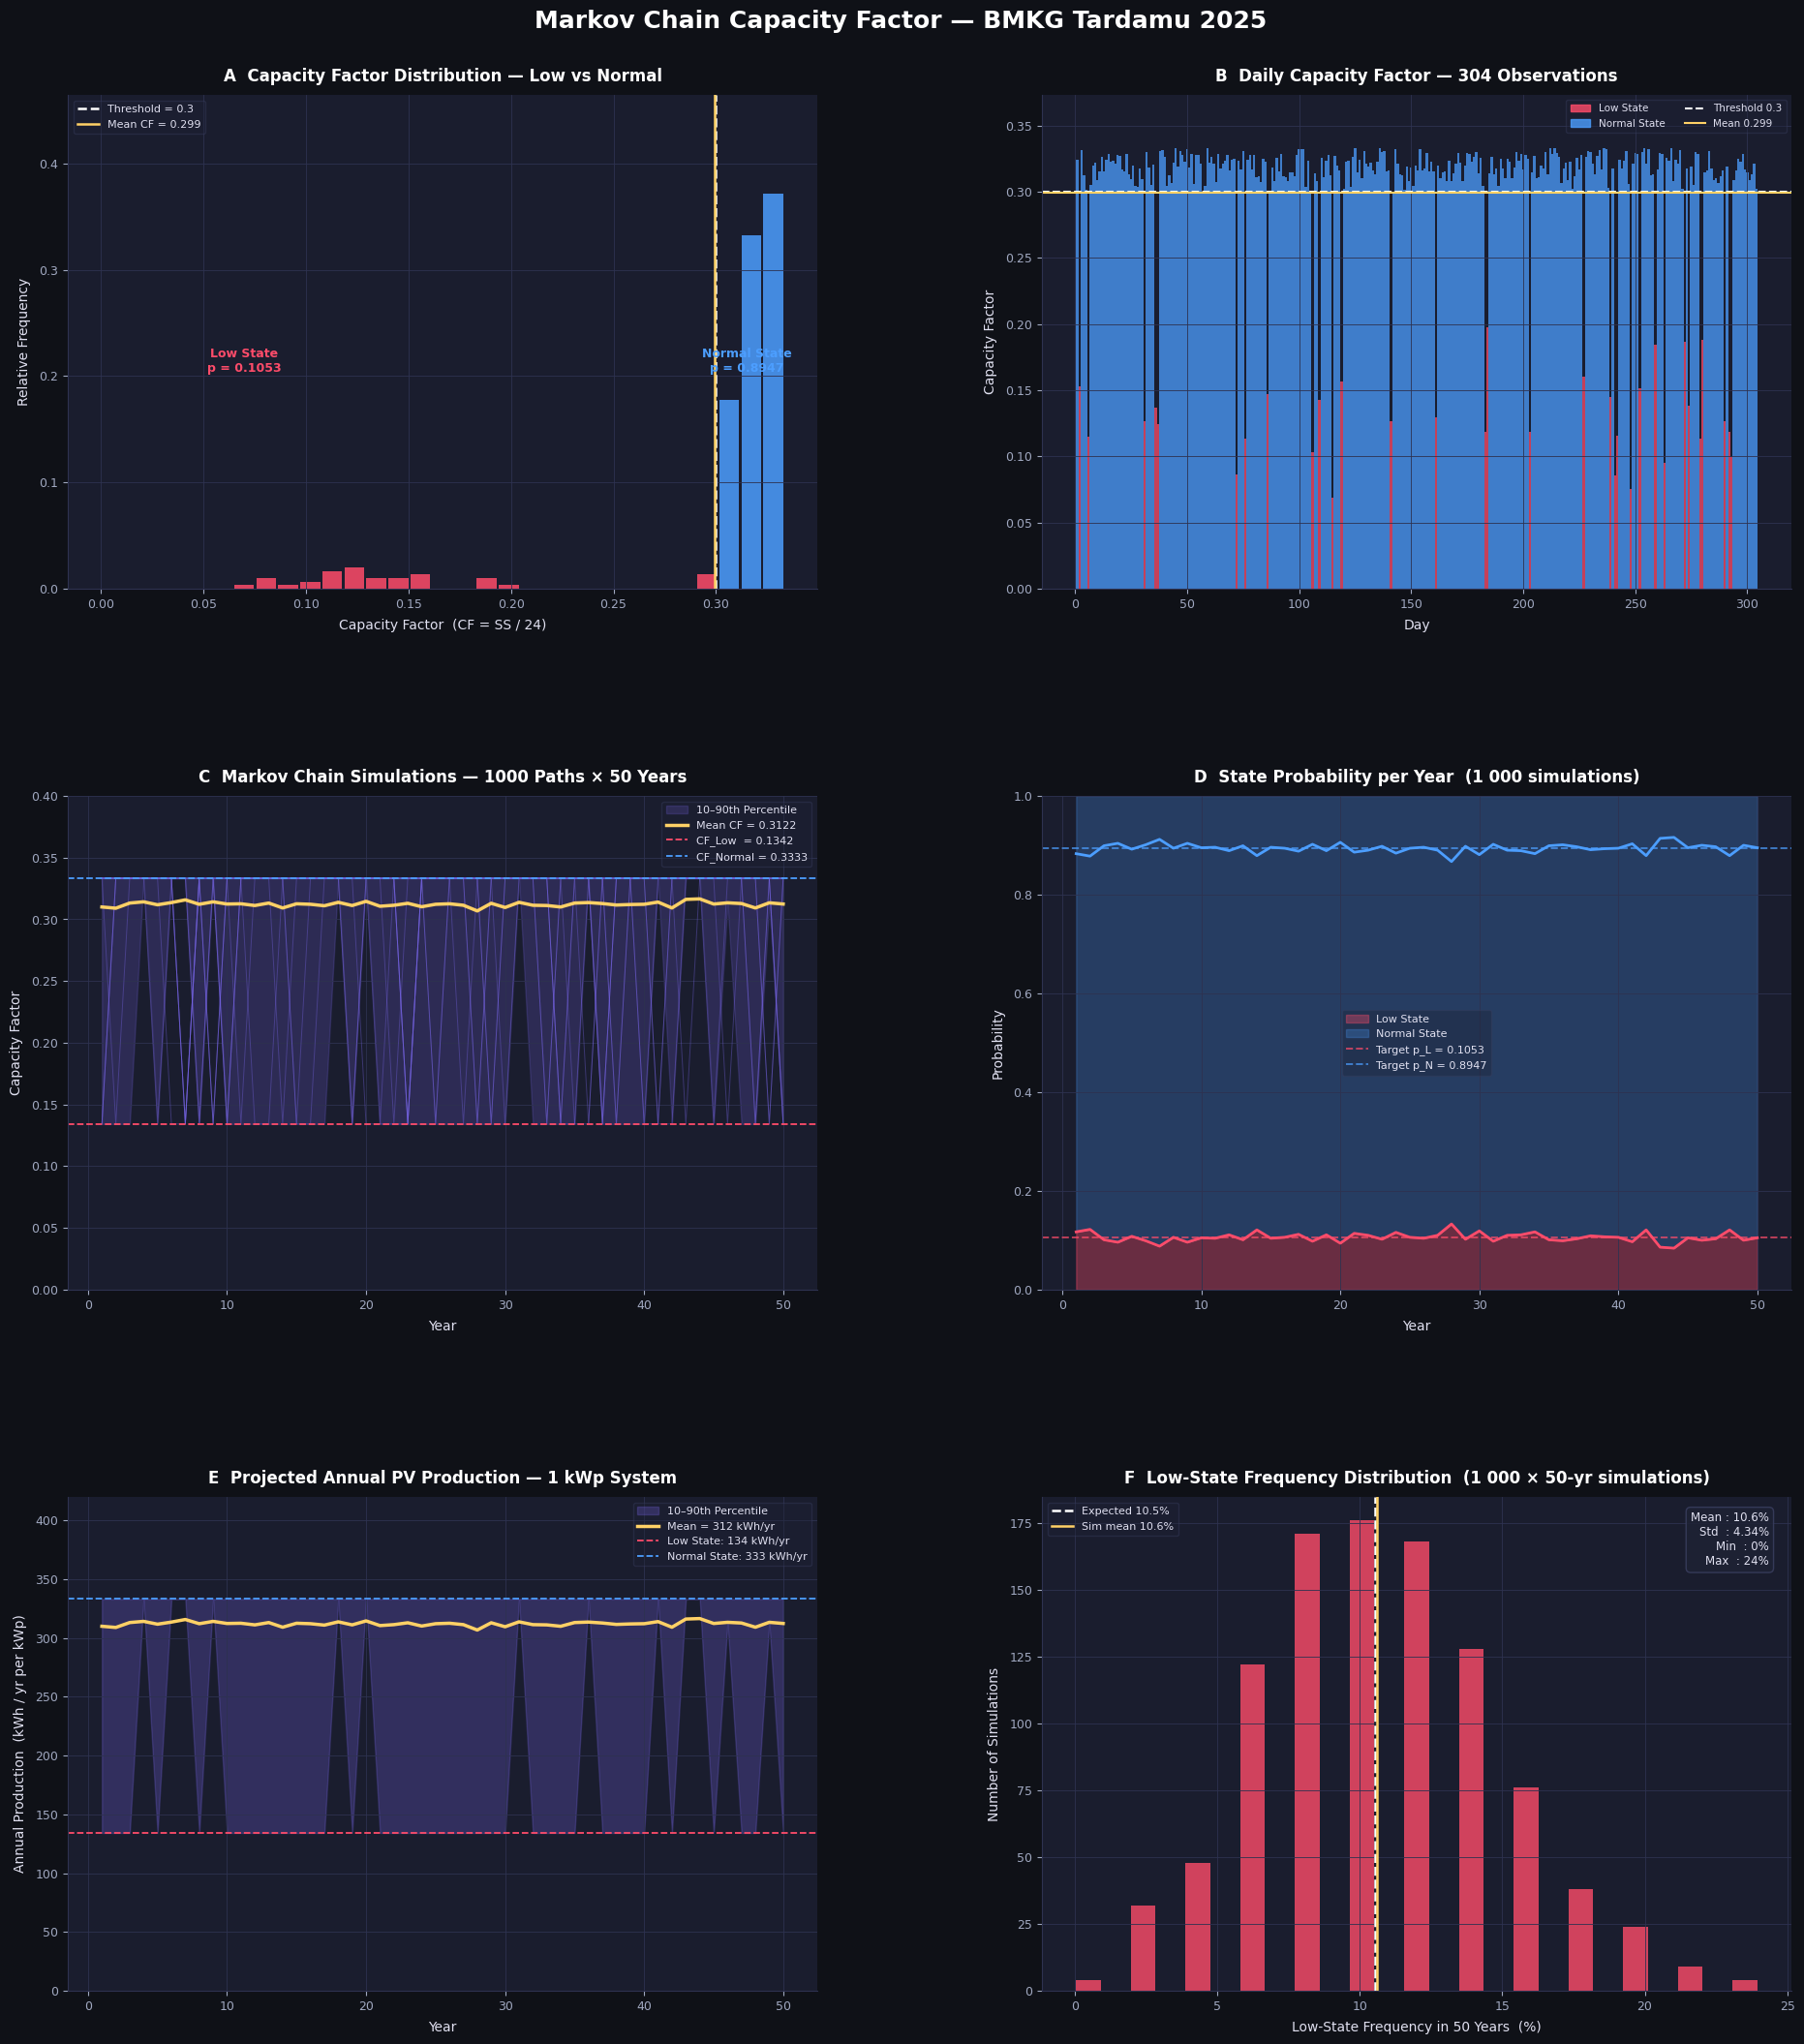

Dashboard saved → Markov_CF_Dashboard.png


In [5]:
# ============================================================================
# 4. MASTER FIGURE  — 6-panel dashboard
# ============================================================================

fig = plt.figure(figsize=(20, 22), facecolor='#0F1117')
fig.suptitle(
    'Markov Chain Capacity Factor — BMKG Tardamu 2025',
    fontsize=18, fontweight='bold', color=C_WHITE, y=0.98
)

gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    hspace=0.42,
    wspace=0.30,
    left=0.07, right=0.96,
    top=0.94, bottom=0.05
)

# ── Helper ──────────────────────────────────────────────────────────────────
def _style(ax, title, xlabel, ylabel, ylim=None):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=10, labelpad=6)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=6)
    if ylim: ax.set_ylim(*ylim)
    ax.tick_params(axis='both', labelsize=9)
    ax.spines[['top','right']].set_visible(False)


# ─────────────────────────────────────────────────────────────────────────────
# Panel A  — CF Histogram with state split
# ─────────────────────────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])

bins    = np.linspace(0, PARAMS['CF_max'], 32)
bin_mid = 0.5 * (bins[:-1] + bins[1:])
low_mask  = bin_mid < PARAMS['threshold']

counts, _ = np.histogram(CF_data, bins=bins)
norm_counts = counts / counts.sum()   # normalise to probability

bar_colors = np.where(low_mask, C_LOW, C_NORM)
ax_A.bar(bin_mid, norm_counts, width=np.diff(bins)[0]*0.9,
         color=bar_colors, alpha=0.85, edgecolor='none')

ax_A.axvline(PARAMS['threshold'], color=C_WHITE, lw=1.8, ls='--', label=f'Threshold = {PARAMS["threshold"]}')
ax_A.axvline(CF_data.mean(),      color=C_MEAN,  lw=1.8, ls='-',  label=f'Mean CF = {CF_data.mean():.3f}')

# Annotate areas
ax_A.text(0.07,  norm_counts.max()*0.55, f'Low State\np = {p_L_emp:.4f}',
          color=C_LOW, fontsize=9, ha='center', fontweight='bold')
ax_A.text(0.315, norm_counts.max()*0.55, f'Normal State\np = {p_N_emp:.4f}',
          color=C_NORM, fontsize=9, ha='center', fontweight='bold')

ax_A.legend(fontsize=8, framealpha=0.4)
_style(ax_A,
       'A  Capacity Factor Distribution — Low vs Normal',
       'Capacity Factor  (CF = SS / 24)',
       'Relative Frequency',
       ylim=(0, norm_counts.max() * 1.25))


# ─────────────────────────────────────────────────────────────────────────────
# Panel B  — Daily CF time-series (first 365 days)
# ─────────────────────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])

n_show = min(365, n)
days   = np.arange(1, n_show + 1)
colors_ts = np.where(state_data[:n_show] == 'Low', C_LOW, C_NORM)

ax_B.bar(days, CF_data[:n_show], width=1, color=colors_ts, alpha=0.75, edgecolor='none')
ax_B.axhline(PARAMS['threshold'], color=C_WHITE, lw=1.5, ls='--', label=f'Threshold {PARAMS["threshold"]}')
ax_B.axhline(CF_data.mean(),      color=C_MEAN,  lw=1.5, ls='-',  label=f'Mean {CF_data.mean():.3f}')

low_patch  = mpatches.Patch(color=C_LOW,  alpha=0.8, label='Low State')
norm_patch = mpatches.Patch(color=C_NORM, alpha=0.8, label='Normal State')
ax_B.legend(handles=[low_patch, norm_patch,
                     Line2D([0],[0], color=C_WHITE, lw=1.5, ls='--', label=f'Threshold {PARAMS["threshold"]}'),
                     Line2D([0],[0], color=C_MEAN,  lw=1.5, label=f'Mean {CF_data.mean():.3f}')],
            fontsize=7.5, framealpha=0.4, ncol=2)
_style(ax_B,
       'B  Daily Capacity Factor — 304 Observations',
       'Day',
       'Capacity Factor',
       ylim=(0, PARAMS['CF_max'] * 1.12))


# ─────────────────────────────────────────────────────────────────────────────
# Panel C  — Markov Chain realisations (10 paths + mean ± band)
# ─────────────────────────────────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 0])

for i in range(min(12, SIM['n_sim'])):
    ax_C.plot(years, CF_mc[i], lw=0.7, alpha=0.35, color=C_BAND)

ax_C.fill_between(years, p10, p90, alpha=0.20, color=C_BAND, label='10–90th Percentile')
ax_C.plot(years, mean_CF, color=C_MEAN, lw=2.5, label=f'Mean CF = {mean_CF.mean():.4f}')

ax_C.axhline(PARAMS['CF_Low'],    color=C_LOW,   lw=1.3, ls='--', label=f'CF_Low  = {PARAMS["CF_Low"]}')
ax_C.axhline(PARAMS['CF_Normal'], color=C_NORM,  lw=1.3, ls='--', label=f'CF_Normal = {PARAMS["CF_Normal"]}')

ax_C.legend(fontsize=8, framealpha=0.4)
_style(ax_C,
       f'C  Markov Chain Simulations — {SIM["n_sim"]} Paths × {SIM["n_years"]} Years',
       'Year',
       'Capacity Factor',
       ylim=(0, 0.40))


# ─────────────────────────────────────────────────────────────────────────────
# Panel D  — State probability evolution
# ─────────────────────────────────────────────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 1])

ax_D.fill_between(years, 0, prob_L, alpha=0.35, color=C_LOW,  label='Low State')
ax_D.fill_between(years, prob_L, 1, alpha=0.25, color=C_NORM, label='Normal State')
ax_D.plot(years, prob_L,  color=C_LOW,  lw=2)
ax_D.plot(years, prob_N,  color=C_NORM, lw=2)

ax_D.axhline(PARAMS['p_L'], color=C_LOW,  lw=1.4, ls='--', alpha=0.7,
             label=f'Target p_L = {PARAMS["p_L"]}')
ax_D.axhline(PARAMS['p_N'], color=C_NORM, lw=1.4, ls='--', alpha=0.7,
             label=f'Target p_N = {PARAMS["p_N"]}')

ax_D.set_ylim(0, 1)
ax_D.legend(fontsize=8, framealpha=0.4)
_style(ax_D,
       'D  State Probability per Year  (1 000 simulations)',
       'Year',
       'Probability')


# ─────────────────────────────────────────────────────────────────────────────
# Panel E  — Annual PV production (kWh per kWp)
# ─────────────────────────────────────────────────────────────────────────────
ax_E = fig.add_subplot(gs[2, 0])

prod_mean = mean_CF * 1000   # kWh/year per kWp  (CF × 1 kWp × 1000 h scale)
prod_p10  = p10    * 1000
prod_p90  = p90    * 1000

ax_E.fill_between(years, prod_p10, prod_p90, alpha=0.25, color=C_BAND, label='10–90th Percentile')
ax_E.plot(years, prod_mean, color=C_MEAN, lw=2.5, label=f'Mean = {prod_mean.mean():.0f} kWh/yr')

ax_E.axhline(PARAMS['CF_Low']    * 1000, color=C_LOW,  lw=1.3, ls='--',
             label=f'Low State: {PARAMS["CF_Low"]*1000:.0f} kWh/yr')
ax_E.axhline(PARAMS['CF_Normal'] * 1000, color=C_NORM, lw=1.3, ls='--',
             label=f'Normal State: {PARAMS["CF_Normal"]*1000:.0f} kWh/yr')

ax_E.legend(fontsize=8, framealpha=0.4)
_style(ax_E,
       'E  Projected Annual PV Production — 1 kWp System',
       'Year',
       'Annual Production  (kWh / yr per kWp)',
       ylim=(0, 420))


# ─────────────────────────────────────────────────────────────────────────────
# Panel F  — Distribution of Low-state frequency across simulations
# ─────────────────────────────────────────────────────────────────────────────
ax_F = fig.add_subplot(gs[2, 1])

hist_counts, hist_bins = np.histogram(pct_low_per_sim, bins=25)
hist_mid   = 0.5 * (hist_bins[:-1] + hist_bins[1:])
ax_F.bar(hist_mid, hist_counts, width=np.diff(hist_bins)[0]*0.9,
         color=C_LOW, alpha=0.80, edgecolor='none')

ax_F.axvline(PARAMS['p_L'] * 100,         color=C_WHITE, lw=1.8, ls='--',
             label=f'Expected {PARAMS["p_L"]*100:.1f}%')
ax_F.axvline(pct_low_per_sim.mean(),       color=C_MEAN,  lw=1.8, ls='-',
             label=f'Sim mean {pct_low_per_sim.mean():.1f}%')

stats_txt = (f"Mean : {pct_low_per_sim.mean():.1f}%\n"
             f"Std  : {pct_low_per_sim.std():.2f}%\n"
             f"Min  : {pct_low_per_sim.min():.0f}%\n"
             f"Max  : {pct_low_per_sim.max():.0f}%")
ax_F.text(0.97, 0.97, stats_txt, transform=ax_F.transAxes,
          fontsize=8.5, va='top', ha='right',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='#1E2235', alpha=0.85,
                    edgecolor='#3A3F60'))

ax_F.legend(fontsize=8, framealpha=0.4)
_style(ax_F,
       'F  Low-State Frequency Distribution  (1 000 × 50-yr simulations)',
       'Low-State Frequency in 50 Years  (%)',
       'Number of Simulations')


# ── Save & show ──────────────────────────────────────────────────────────────
plt.savefig('Markov_CF_Dashboard.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Dashboard saved → Markov_CF_Dashboard.png")

In [6]:
# ============================================================================
# 5. SUMMARY TABLE
# ============================================================================

summary = pd.DataFrame({
    'Parameter':  ['N obs', 'p_Low', 'p_Normal', 'CF_Low', 'CF_Normal',
                   'Mean CF', 'Stationary π_Low', 'Stationary π_Normal',
                   'Mean annual production (kWh/yr per kWp)'],
    'Document':   [304, 0.1053, 0.8947, 0.1342, 0.3333,
                   0.3123, '—', '—', '—'],
    'Simulated':  [n, round(p_L_emp, 4), round(p_N_emp, 4),
                   round(CF_L_emp, 4), round(CF_N_emp, 4),
                   round(CF_data.mean(), 4),
                   round(pi[0], 4), round(pi[1], 4),
                   round(mean_CF.mean() * 1000, 1)],
})

print("\n" + "="*65)
print("  SUMMARY — Document vs Simulation")
print("="*65)
print(summary.to_string(index=False))
print("="*65)


  SUMMARY — Document vs Simulation
                              Parameter Document  Simulated
                                  N obs      304   304.0000
                                  p_Low   0.1053     0.1053
                               p_Normal   0.8947     0.8947
                                 CF_Low   0.1342     0.1295
                              CF_Normal   0.3333     0.3195
                                Mean CF   0.3123     0.2995
                       Stationary π_Low        —     0.1053
                    Stationary π_Normal        —     0.8947
Mean annual production (kWh/yr per kWp)        —   312.2000
